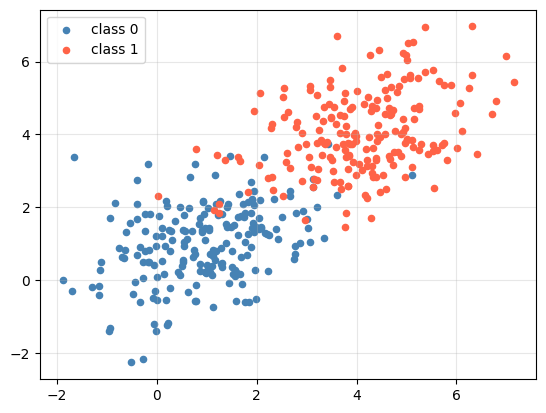

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

np.random.seed(42)

mu0=np.array([1.0,1.0])
mu1=np.array([4.0,4.0])
sigma=np.array([[1.5,0.5],[0.5,1.2]])
n=200
X0=np.random.multivariate_normal(mu0,sigma,n)
X1=np.random.multivariate_normal(mu1,sigma,n)

X = np.vstack([X0, X1]) 
y = np.array([0]*n + [1]*n)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

plt.scatter(X0[:,0],X0[:,1],color='steelblue',s=20,label='class 0')
plt.scatter(X1[:,0],X1[:,1],color='tomato',s=20,label='class 1')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [6]:
class GDA:
    def fit(self,X,y):
        m=len(y)
        self.phi=np.mean(y==1)
        self.mu0=X[y==0].mean(axis=0)
        self.mu1=X[y==1].mean(axis=0)

        X_centered=np.where((y==0).reshape(-1,1),X-self.mu0,X-self.mu1)
        self.sigma=(1/m)*X_centered.T @X_centered
        self.sigma_inv=np.linalg.inv(self.sigma)
        self.sigma_det=np.linalg.det(self.sigma)

        return self
    def _gaussian_pdf(self,X,mu):
        k=X.shape[1]
        diff=X-mu

        norm_const=1/((2*np.pi*self.sigma_det)**0.5)
        exponent = -0.5 * np.einsum('ij,jk,ik->i', diff, self.sigma_inv, diff)

        return norm_const*np.exp(exponent)
    
    def predict_proba(self,X):
        likelihood0 = self._gaussian_pdf(X, self.mu0) #P(X|Y=0)
        likelihood1 = self._gaussian_pdf(X, self.mu1)

        prior0=1-self.phi
        prior1=self.phi

        p0=likelihood0*prior0
        p1=likelihood1*prior1

        total=p0+p1
        return p1/total
    
    def predict(self,X,threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)
    
gda = GDA().fit(X_train, y_train)
print("φ (P(y=1): ",gda.phi)
print("μ₀: ",gda.mu0)
print("μ₁: ",gda.mu1)
print("Σ: ",gda.sigma)



φ (P(y=1):  0.5125
μ₀:  [0.97646776 1.01992673]
μ₁:  [4.09012616 4.03508237]
Σ:  [[1.38071846 0.56095296]
 [0.56095296 1.23512029]]


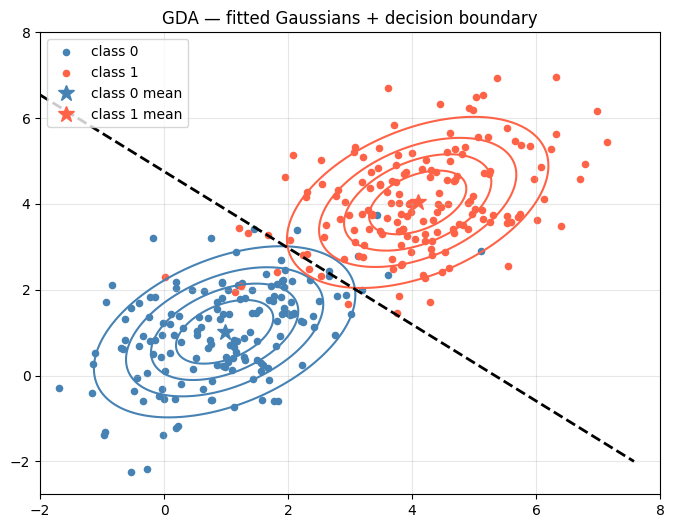

In [9]:
def plot_gaussian_contours(mu,sigma,color,label,ax):
    x1=np.linspace(-2,8,200)
    x2 = np.linspace(-2, 8, 200)
    X1,X2=np.meshgrid(x1,x2)
    grid=np.c_[X1.ravel(),X2.ravel()]
    diff=grid-mu
    sigma_inv=np.linalg.inv(sigma)
    exponent = -0.5 * np.einsum('ij,jk,ik->i', diff, sigma_inv, diff)
    Z=np.exp(exponent).reshape(X1.shape)
    ax.contour(X1,X2,Z,levels=4,colors=color,linewidths=1.5)
    ax.plot(mu[0],mu[1],'*',color=color,markersize=12,label=f"{label} mean")

fig,ax=plt.subplots(figsize=(8,6))

ax.scatter(X_train[y_train==0][:,0],X_train[y_train==0][:,1],color='steelblue',s=20,label='class 0')
ax.scatter(X_train[y_train==1][:,0],X_train[y_train==1][:,1],color='tomato',s=20,label='class 1')

plot_gaussian_contours(gda.mu0,gda.sigma,'steelblue','class 0',ax)
plot_gaussian_contours(gda.mu1,gda.sigma,'tomato','class 1',ax)

x1=np.linspace(-2,8,300)
x2=np.linspace(-2,8,300)
X1,X2=np.meshgrid(x1,x2)
grid=np.c_[X1.ravel(),X2.ravel()]
grid = np.c_[X1.ravel(), X2.ravel()]
Z = gda.predict_proba(grid).reshape(X1.shape)

ax.contour(X1, X2, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')
ax.set_title("GDA — fitted Gaussians + decision boundary")
ax.legend(); ax.grid(alpha=0.3); plt.show()

Accuracy on Gaussian data: 
GDA: 0.963
Logistic Regression: 0.975


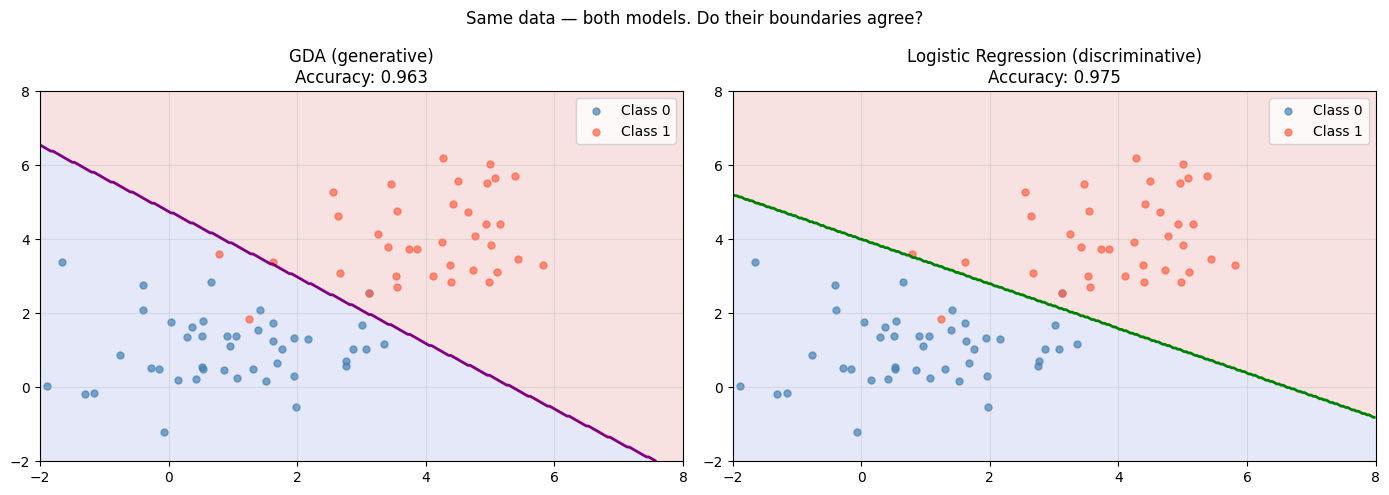

In [11]:
lr=LogisticRegression()
lr.fit(X_train,y_train)

y_pred_gda=gda.predict(X_test)
y_pred_lr=lr.predict(X_test)

print("Accuracy on Gaussian data: ")
print(f"GDA: {accuracy_score(y_test, y_pred_gda):.3f}")
print(f"Logistic Regression: {accuracy_score(y_test, y_pred_lr):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model, name, color in zip(
    axes,
    [gda, lr],
    ['GDA (generative)', 'Logistic Regression (discriminative)'],
    ['purple', 'green']
):
    Z=(gda.predict(grid) if model is gda else lr.predict(grid.reshape(-1,2))).reshape(X1.shape)
    ax.contourf(X1, X2, Z, alpha=0.15, cmap='coolwarm')
    ax.contour(X1, X2, Z, levels=[0.5], colors=color, linewidths=2)

    ax.scatter(X_test[y_test==0][:,0], X_test[y_test==0][:,1],
            color='steelblue', s=25, alpha=0.7, label='Class 0')
    ax.scatter(X_test[y_test==1][:,0], X_test[y_test==1][:,1],
            color='tomato', s=25, alpha=0.7, label='Class 1')
    ax.set_title(f"{name}\nAccuracy: {accuracy_score(y_test, gda.predict(X_test) if model is gda else y_pred_lr):.3f}")
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Same data — both models. Do their boundaries agree?", fontsize=12)
plt.tight_layout(); plt.show()